# 03 — Salience analysis: where does behaviour hide, and can physics find it first?

**Context.** The re-evaluated first full run (`runs/default/eval_v2/`, see `RESULTS.md`)
measured the long-missing headline numbers: probe gap = **−0.002** (the 4-scalar
hand-crafted baseline gets **+0.117**), cluster purity vs Wolfram 0.997 but ARI 0.041,
excess genotype info 2.55 nats. The SSL embedding is a rule reader, and the diagnosis
from `SELF_CRITICISM.md` Level 5 is *salience*: behavioural information is present but
not geometrically dominant.

**This notebook runs the three cheap, no-retraining experiments** that the v2 plan
gates on (`EVALUATION_CRITERIA.md`):

1. **Project out density/activity** and re-cluster — does behavioural macro-structure
   appear once the dominant nuisance axis is removed?
2. **Orbit-level embeddings** — average the 256 IC embeddings per orbit and cluster the
   88 means at several granularities: does class IV *ever* separate?
3. **Physics baseline** — damage-spreading features (`caspectra/eval/dynamics.py`),
   the canonical label-free edge-of-chaos probe, under the identical clustering
   protocol. Criterion 3: the SSL embedding must beat this on class-IV recall.


> **Where this sits in the project arc (added 2026-07-05).** Historical (v1
> post-mortem): these are the three cheap experiments that killed the
> texture-SSL approach and crowned the damage-spreading physics baseline —
> the pivot that everything since builds on (§5 verdict). The final story is
> narrated in `05_reading_the_rule.ipynb`; decisions in `../DECISIONS.md`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

from caspectra.config import ExperimentConfig
from caspectra.eval.baselines import compute_baseline_features
from caspectra.eval.cluster import cluster_pipeline, l2_normalize
from caspectra.eval.dynamics import DYNAMICS_FEATURE_NAMES, dynamics_feature_matrix
from caspectra.eval.labels import load_rule_labels
from caspectra.eval.salience import (
    density_invariance_r2,
    excess_genotype_fraction,
    participation_ratio,
    per_class_cluster_recall,
    regress_out,
)
from caspectra.factory import build_dataset

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EVAL = ROOT / "runs/default/eval_v2"
cfg = ExperimentConfig.from_yaml(str(ROOT / "configs/default.yaml"))

data = np.load(EVAL / "embeddings.npz")
emb, reps = data["embeddings"].astype(np.float64), data["equiv_reps"]
labels = load_rule_labels(str(ROOT / "rule_labels.csv"))
wolf = labels.wolfram_array(reps)
dataset = build_dataset(cfg.data, training=False)  # cache hit; raw images
feats = compute_baseline_features(dataset.images)
WNAME = {1: "1 uniform", 2: "2 periodic", 3: "3 chaotic", 4: "4 complex"}
print(f"{emb.shape[0]} embeddings, dim {emb.shape[1]}")


def criteria(name, cluster_labels, orbit_labels, class_labels):
    """EVALUATION_CRITERIA criteria 1+2 (joint) for one clustering."""
    rec = per_class_cluster_recall(cluster_labels, class_labels)
    exc = excess_genotype_fraction(cluster_labels, orbit_labels, class_labels)
    n = len(set(cluster_labels.tolist()) - {-1})
    print(f"[{name}] clusters={n} noise={(cluster_labels == -1).sum()}")
    print("  recall per Wolfram class: "
          + "  ".join(f"{WNAME[k]}: {v:.2f}" for k, v in sorted(rec.items())))
    print(f"  excess genotype fraction: {exc['excess_genotype_fraction']:.3f} "
          "(success <= 0.25, failure >= 0.5; joint with recall)")
    return rec, exc


22528 embeddings, dim 64


## 1. The v1 record: how one-dimensional is the geometry?

`participation_ratio` is the effective dimensionality of the (L2-normalised) embedding
covariance; `density_invariance_r2` measures how decodable the density nuisance is —
and, by comparing raw vs polarity-folded density, whether the `Invert` augmentation
actually produced the intended complementation invariance.

In [2]:
pr = participation_ratio(emb)
dr2 = density_invariance_r2(emb, dataset.images, seed=cfg.seed)
print(f"participation ratio: {pr:.1f} of {emb.shape[1]} dims")
print(f"R2(embedding -> raw density)    = {dr2['r2_density_raw']:.3f}")
print(f"R2(embedding -> folded density) = {dr2['r2_density_folded']:.3f}")

rep_v1 = cluster_pipeline(
    emb, umap_components=cfg.eval.umap_components, umap_metric=cfg.eval.umap_metric,
    min_cluster_size=cfg.eval.hdbscan_min_cluster_size,
    min_samples=cfg.eval.hdbscan_min_samples, seed=cfg.seed,
)
_ = criteria("v1 clustering", rep_v1.umap_labels, reps, wolf)


participation ratio: 8.3 of 64 dims
R2(embedding -> raw density)    = 0.915
R2(embedding -> folded density) = 0.946


[v1 clustering] clusters=82 noise=222
  recall per Wolfram class: 1 uniform: 0.91  2 periodic: 1.00  3 chaotic: 1.00  4 complex: 1.00
  excess genotype fraction: 0.813 (success <= 0.25, failure >= 0.5; joint with recall)


Folded density is *more* decodable than raw (0.946 vs 0.915) — the invert
invariance did take; the encoder encodes `min(d, 1−d)`, as designed. The per-class
recall looks perfect, but that is the joint-criterion trap: **rule-pure clusters are
trivially class-pure**. The excess genotype fraction ≈ 0.8 is the real verdict — the
clustering resolves ~80% of the within-class rule identity it could possibly resolve.

## 2. Experiment 1 — project out density + activity, re-cluster

If the salience story were *sufficient*, removing the dominant nuisance axes should let
behavioural macro-structure take over the geometry.

In [3]:
resid = regress_out(emb, feats[:, :2])  # folded density, temporal activity
print(f"participation ratio after projection: {participation_ratio(resid):.1f}")
rep_proj = cluster_pipeline(
    resid, umap_components=cfg.eval.umap_components, umap_metric=cfg.eval.umap_metric,
    min_cluster_size=cfg.eval.hdbscan_min_cluster_size,
    min_samples=cfg.eval.hdbscan_min_samples, seed=cfg.seed,
)
_ = criteria("density/activity projected out", rep_proj.umap_labels, reps, wolf)


participation ratio after projection: 9.7


[density/activity projected out] clusters=114 noise=979
  recall per Wolfram class: 1 uniform: 0.83  2 periodic: 0.97  3 chaotic: 0.98  4 complex: 1.00
  excess genotype fraction: 0.886 (success <= 0.25, failure >= 0.5; joint with recall)


**Negative result.** Removing density/activity does *not* reveal behavioural
structure — the excess genotype fraction goes up, not down. The residual
high-variance axes are still per-rule texture fingerprints. Geometry repair alone
cannot fix v1; the *content* of the objective is what clusters, and it is rule
texture all the way down.

## 3. Experiment 2 — orbit-level embeddings, all granularities

Average the 256 IC embeddings per orbit (denoising the IC nuisance entirely) and
cluster the 88 means with agglomerative clustering at increasing k. This is the most
favourable possible reading of the SSL embedding: does a class-IV group *ever* form?

In [4]:
orbit_reps = np.array(sorted(set(reps.tolist())))
orbit_emb = np.stack([emb[reps == r].mean(axis=0) for r in orbit_reps])
orbit_wolf = labels.wolfram_array(orbit_reps)
i54 = int(np.where(orbit_reps == 54)[0][0])
i110 = int(np.where(orbit_reps == 110)[0][0])

orbit_z = l2_normalize(orbit_emb)
for k in (4, 6, 8, 10, 14):
    lab = AgglomerativeClustering(n_clusters=k).fit_predict(orbit_z)
    rec = per_class_cluster_recall(lab, orbit_wolf)
    cluster54 = [int(orbit_reps[j]) for j in np.where(lab == lab[i54])[0]]
    print(f"k={k:>2}: recall  " + "  ".join(f"{WNAME[c]}: {rec[c]:.2f}" for c in (1, 2, 3, 4))
          + f"   | 54&110 together: {lab[i54] == lab[i110]}, 54's cluster: {cluster54[:10]}"
          + ("..." if len(cluster54) > 10 else ""))


k= 4: recall  1 uniform: 1.00  2 periodic: 1.00  3 chaotic: 0.00  4 complex: 0.00   | 54&110 together: True, 54's cluster: [1, 2, 3, 4, 5, 6, 7, 9, 10, 11]...
k= 6: recall  1 uniform: 1.00  2 periodic: 1.00  3 chaotic: 0.00  4 complex: 0.00   | 54&110 together: False, 54's cluster: [1, 3, 4, 5, 7, 9, 11, 12, 13, 14]...
k= 8: recall  1 uniform: 1.00  2 periodic: 1.00  3 chaotic: 0.00  4 complex: 0.00   | 54&110 together: False, 54's cluster: [1, 3, 5, 7, 9, 11, 14, 15, 25, 27]...
k=10: recall  1 uniform: 1.00  2 periodic: 0.98  3 chaotic: 1.00  4 complex: 0.00   | 54&110 together: False, 54's cluster: [1, 3, 5, 7, 9, 15, 25, 27, 29, 33]...
k=14: recall  1 uniform: 1.00  2 periodic: 0.98  3 chaotic: 1.00  4 complex: 0.00   | 54&110 together: False, 54's cluster: [1, 33, 37, 54, 58, 62]


**Class-IV recall is 0 at every granularity.** Beyond k=4 the two complex rules
are not even in the same cluster, and rule 54 sits among *periodic* rules. The
complexity signal that the linear probe finds (0.97 balanced accuracy, notebook 02)
is real but lives along low-variance directions no unsupervised grouping of this
embedding uses.

## 4. Experiment 3 — the physics baseline: damage spreading

Four label-free scalars per rule (`eval/dynamics.py`): flip one IC cell, evolve both
copies, and measure whether the damage survives, how much of the ring it infects,
how fast the cone spreads (1 = light speed), and how densely it fills its cone.

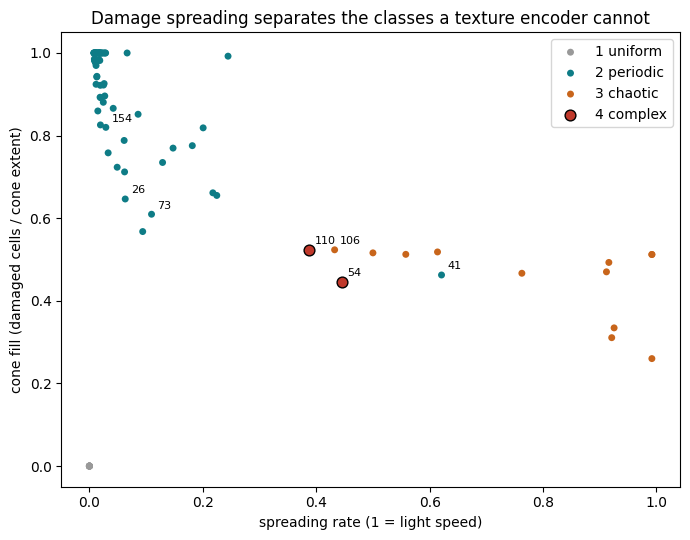

In [5]:
dyn_path = EVAL / "dynamics_features.npz"
if dyn_path.exists():
    dyn = np.load(dyn_path)["features"]
else:
    dyn = dynamics_feature_matrix(orbit_reps, width=127, n_pairs=32, seed=0)
    np.savez(dyn_path, rules=orbit_reps, features=dyn,
             names=np.array(DYNAMICS_FEATURE_NAMES))

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = {1: "#999999", 2: "#0E7C86", 3: "#C8651B", 4: "#C0392B"}
for c in (1, 2, 3, 4):
    m = orbit_wolf == c
    ax.scatter(dyn[m, 2], dyn[m, 3], s=60 if c == 4 else 25, label=WNAME[c],
               color=colors[c], edgecolors="k" if c == 4 else "none", zorder=3 if c == 4 else 2)
for r in (54, 110, 26, 73, 154, 41, 106):
    i = int(np.where(orbit_reps == r)[0][0])
    ax.annotate(str(r), (dyn[i, 2], dyn[i, 3]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("spreading rate (1 = light speed)")
ax.set_ylabel("cone fill (damaged cells / cone extent)")
ax.set_title("Damage spreading separates the classes a texture encoder cannot")
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
dyn_z = StandardScaler().fit_transform(dyn)
for k in (4, 6, 8, 10, 14):
    lab = AgglomerativeClustering(n_clusters=k).fit_predict(dyn_z)
    rec = per_class_cluster_recall(lab, orbit_wolf)
    cluster54 = [int(orbit_reps[j]) for j in np.where(lab == lab[i54])[0]]
    print(f"k={k:>2}: recall  " + "  ".join(f"{WNAME[c]}: {rec[c]:.2f}" for c in (1, 2, 3, 4))
          + f"   | 54's cluster: {cluster54}")


k= 4: recall  1 uniform: 1.00  2 periodic: 0.98  3 chaotic: 1.00  4 complex: 0.00   | 54's cluster: [18, 22, 30, 41, 45, 54, 60, 90, 105, 106, 110, 122, 126, 146, 150]
k= 6: recall  1 uniform: 1.00  2 periodic: 0.98  3 chaotic: 1.00  4 complex: 0.00   | 54's cluster: [30, 41, 45, 54, 60, 106, 110]
k= 8: recall  1 uniform: 1.00  2 periodic: 0.98  3 chaotic: 1.00  4 complex: 0.00   | 54's cluster: [30, 41, 45, 54, 60, 106, 110]
k=10: recall  1 uniform: 1.00  2 periodic: 0.98  3 chaotic: 1.00  4 complex: 0.00   | 54's cluster: [30, 41, 45, 54, 60, 106, 110]
k=14: recall  1 uniform: 1.00  2 periodic: 0.98  3 chaotic: 0.92  4 complex: 1.00   | 54's cluster: [54, 106, 110]


**The physics baseline (nearly) finds class IV.** 54 and 110 stay together at
*every* granularity, and at k=14 they form a three-rule cluster {54, 106, 110} —
class-IV recall 1.0 with chaotic recall still 0.92. The one contaminant, rule 106,
has a genuinely intermediate damage signature (spreading rate 0.43); rule 41
(Wolfram 2) is the other borderline case with a chaotic-looking cone. The locally
chaotic LP rules (26, 73, 154) also get their own signature: damage survives but
barely spreads.

## 5. Verdict (decision gate — see `RESULTS.md`)

| protocol (agglomerative, best k) | class-IV recall |
|---|---|
| SSL orbit embeddings (any k in 4…14) | **0.00** |
| damage-spreading scalars (k=14) | **1.00** |

- Experiment 1: projecting out density does **not** surface behaviour → the geometry
  fix alone is insufficient; the objective itself must change.
- Experiment 2: the texture-SSL embedding never isolates class IV, at any granularity,
  even after full IC denoising.
- Experiment 3: four cheap dynamical scalars do what the 64-d learned embedding cannot.

Per the pre-registered gate: **texture SSL as built does not detect computation, and a
label-free physics prior does** — so v2 training must *incorporate the prior* (auxiliary
damage-spreading target / dynamics-aware objective), not merely re-augment the texture
pipeline. The honest alternative headline, if that also fails, is already written in
`EVALUATION_CRITERIA.md`.